In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors._kde import KernelDensity

In [5]:
sigma = 2 # Variance of the entire distribution
x = np.random.normal(size=(10000, 1000), scale=sigma) # A random 10000 x 1000 matrix

In [7]:
x.shape

(10000, 1000)

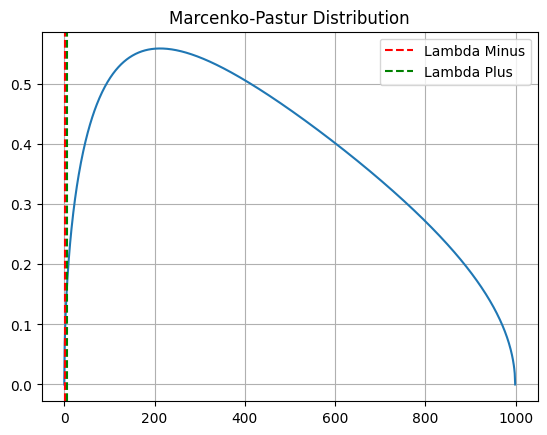

In [ ]:
q = float(10000 / 1000) # Aspect ratio

# Lower and upper limits
lower_limit = sigma**2 * (1 - np.sqrt(1.0 / q)) ** 2
upper_limit = sigma**2 * (1 + np.sqrt(1.0 / q)) ** 2

# Getting the x-values
lambda_values = np.linspace(lower_limit, upper_limit, 1000)

# Getting the y-values
pdf = q / (2 * np.pi * sigma * lambda_values) * np.sqrt(((upper_limit - lambda_values) * (lambda_values - lower_limit)))
pdf = pd.Series(pdf) # , index=eVal

# Plotting the graph
plt.plot(pdf.index, pdf.values)
plt.title("Marcenko-Pastur Distribution")
plt.axvline(x=lower_limit, color="r", linestyle="--", label="Lambda Minus")
plt.axvline(x=upper_limit, color="g", linestyle="--", label="Lambda Plus")
plt.legend()
plt.grid(True)
plt.show()

In [10]:
# Getting the eigenvalues and eigenvectors using the hermitian matrix
eVal, eVec = np.linalg.eigh(np.cov(x, rowvar=0))

# Sorting the eigenvalues and eigenvectors in decending order
indices = eVal.argsort()[::-1]
eVal, eVec = eVal[indices], eVec[:, indices]

In [11]:
kde = KernelDensity(kernel="gaussian", bandwidth=0.01).fit(eVal.reshape(-1, 1))
x = np.unique(eVal).reshape(-1, 1)
logProb = kde.score_samples(x)
kde_pdf = pd.Series(np.exp(logProb), index=x.flatten())

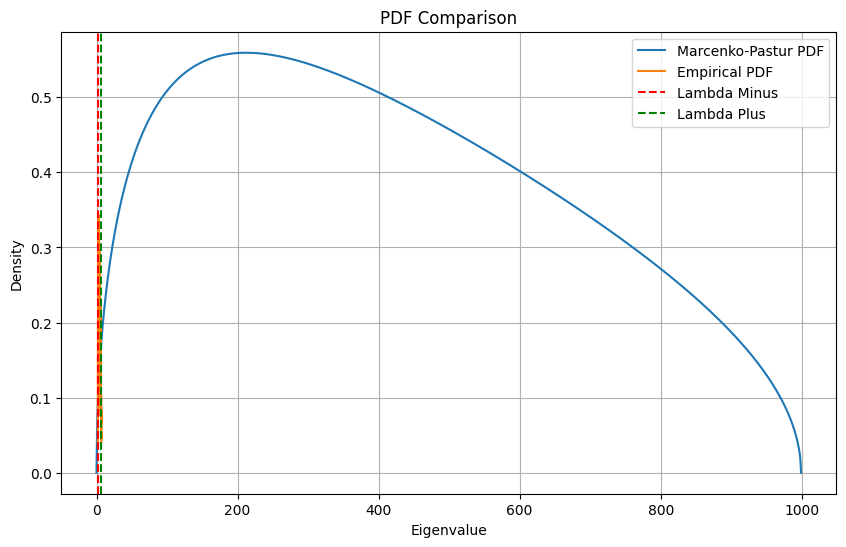

In [12]:
plt.figure(figsize=(10, 6))
plt.plot(pdf.index, pdf.values, label="Marcenko-Pastur PDF")
plt.plot(kde_pdf.index, kde_pdf.values, label="Empirical PDF")
plt.axvline(x=lower_limit, color="r", linestyle="--", label="Lambda Minus")
plt.axvline(x=upper_limit, color="g", linestyle="--", label="Lambda Plus")
plt.title("PDF Comparison")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.legend()
plt.grid(True)
plt.show()